In [92]:
import re
import unicodedata
from collections import Counter
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, ops
from tensorflow.keras.layers import Input, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

import torch
from torch.utils.data import Dataset

from transformers import (
    MarianMTModel,
    MarianTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
)

from tqdm.auto import tqdm
from tqdm import trange
from tqdm.keras import TqdmCallback

In [93]:
df = pd.read_csv('dataset_100k.csv')

# EDA

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      100000 non-null  object
 1   en      100000 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


In [95]:
df.head(5)

,id,en
0,"Nah , Anda masih seperti anak bagi saya , Daryl .","Well, you're still like a son to me, Daryl."
1,Jangan datang lagi.,Lee Seung Chul.
2,"Uh, Maukah anda menggambarkan suaranya?","Uh, how would you describe the sound?"
3,Aku ada di sana malam ini.,I was there tonight.
4,Aku seorang Greyjoy.,I'm a Greyjoy.


In [96]:
print("Null values:")
print(df.isnull().sum())

Null values:
id    0
en    0
dtype: int64


Tidak ada null value

In [97]:
print("Duplicate rows:")
print(df.duplicated().sum())

Duplicate rows:
0


Tidak ada data duplikat

In [98]:
df['en'] = df['en'].astype(str)
df['id'] = df['id'].astype(str)

In [99]:
df['en_len'] = df['en'].apply(lambda x: len(x.split()))
df['id_len'] = df['id'].apply(lambda x: len(x.split()))

In [100]:
df['len_ratio'] = df['en_len'] / df['id_len']
df['len_diff'] = abs(df['en_len'] - df['id_len'])

In [101]:
df[['en_len', 'id_len', 'len_ratio', 'len_diff']].describe()

,en_len,id_len,len_ratio,len_diff
count,100000.00000,100000.000000,100000.000000,100000.000000
mean,6.88170,5.866600,1.256844,1.588320
std,4.62225,3.927518,0.618305,1.872927
min,1.00000,1.000000,0.058824,0.000000
25%,4.00000,3.000000,1.000000,0.000000
50%,6.00000,5.000000,1.142857,1.000000
75%,9.00000,7.000000,1.400000,2.000000
max,64.00000,61.000000,24.500000,47.000000


- Dataset terdiri 100.000 pasangan kalimat dalam bahasa Inggris (`en`) dan bahasa Indonesia (`id`).
- Rata-rata panjang kalimat bahasa Inggris sekitar 6,88 kata, sedangkan rata-rata kalimat bahasa Indonesia adalah 5,87 kata.
- Rata-rata `len_ratio` sebesar 1,26 artinya secara umum kalimat bahasa Inggris cenderung sedikit lebih panjang dibandingkan kalimat bahasa Indonesia.
- Sebagian besar pasangan kalimat memiliki perbedaan panjang yang kecil, terlihat dari nilai median (`50%`) `len_diff` sebesar 1 kata.
- Panjang maksimum kalimat 64 kata untuk bahasa Inggris dan 61 kata untuk bahasa Indonesia, menunjukkan adanya beberapa pasangan kalimat yang cukup panjang dalam dataset.
- Nilai maksimum `len_ratio` yang cukup besar (24,5) mengindikasikan kemungkinan terdapat beberapa data yang tidak seimbang, noisy, atau pasangan terjemahan yang kurang sesuai sehingga perlu diperiksa lebih lanjut pada tahap preprocessing.

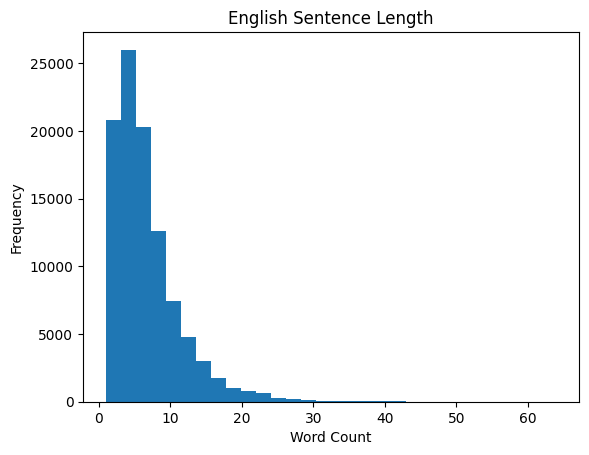

In [102]:
plt.hist(df['en_len'], bins=30)
plt.title("English Sentence Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

- Histogram menunjukkan bahwa sebagian besar kalimat bahasa Inggris memiliki panjang sekitar 3–10 kata.
- Distribusi bersifat right-skewed (miring ke kanan), yang berarti sebagian besar kalimat pendek, namun terdapat sejumlah kecil kalimat yang sangat panjang.

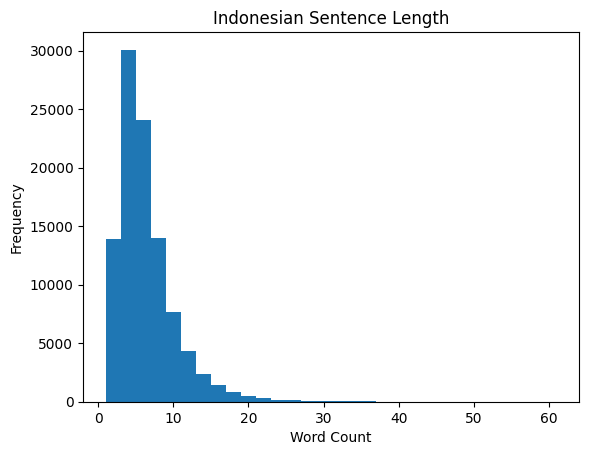

In [103]:
plt.hist(df['id_len'], bins=30)
plt.title("Indonesian Sentence Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

- Pola distribusi kalimat bahasa Indonesia mirip dengan bahasa Inggris, dengan mayoritas panjang kalimat berada pada rentang 2–8 kata.
- Distribusi juga menunjukkan bentuk right-skewed, menandakan bahwa dataset didominasi oleh kalimat pendek hingga menengah.

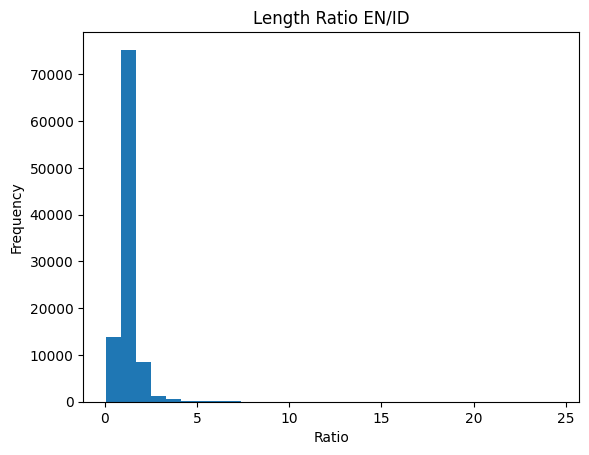

In [104]:
plt.hist(df['len_ratio'].dropna(), bins=30)
plt.title("Length Ratio EN/ID")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.show()

- Histogram menunjukkan bahwa sebagian besar nilai rasio panjang kalimat (`EN/ID`) berada di sekitar 1.0–1.5.
- Hal ini menandakan bahwa panjang kalimat bahasa Inggris dan bahasa Indonesia relatif seimbang pada sebagian besar pasangan data.
- Distribusinya right-skewed, dengan sejumlah kecil data memiliki rasio yang sangat besar.
- Rasio yang terlalu tinggi biasanya menunjukkan adanya pasangan kalimat di mana panjang kalimat bahasa Inggris jauh lebih panjang dibandingkan bahasa Indonesia, atau sebaliknya.

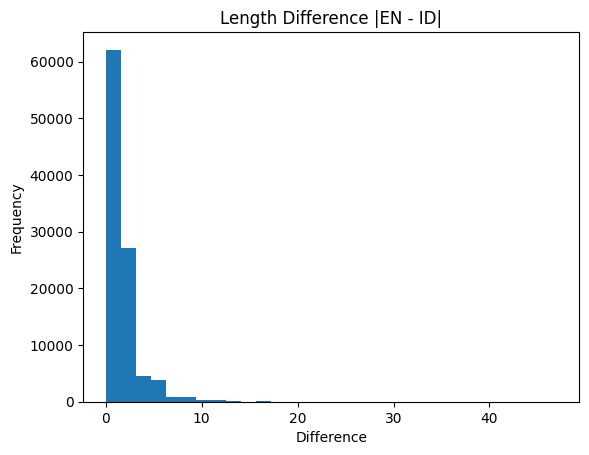

In [105]:
plt.hist(df['len_diff'], bins=30)
plt.title("Length Difference |EN - ID|")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.show()

- Sebagian besar pasangan kalimat memiliki perbedaan panjang yang kecil, terutama pada rentang 0–3 kata.
- Hal ini menunjukkan bahwa mayoritas pasangan terjemahan memiliki struktur dan panjang yang relatif seimbang.
- Terdapat beberapa outlier dengan perbedaan panjang yang cukup besar, yang dapat mengindikasikan adanya data noisy atau pasangan terjemahan yang kurang selaras.

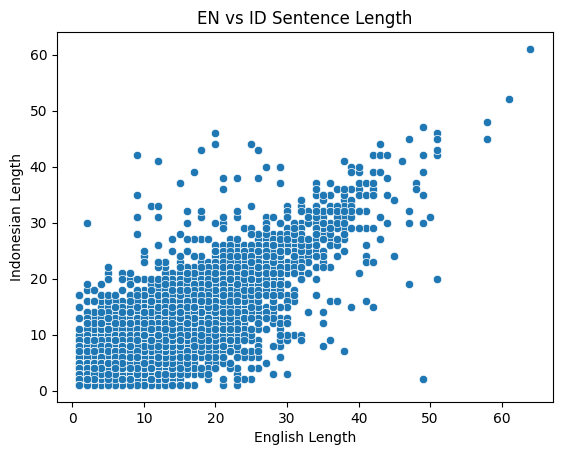

In [106]:
sns.scatterplot(x=df['en_len'], y=df['id_len'])
plt.title("EN vs ID Sentence Length")
plt.xlabel("English Length")
plt.ylabel("Indonesian Length")
plt.show()

In [107]:
corr = df['en_len'].corr(df['id_len'])
print("Length correlation:", corr)

Length correlation: 0.8755768433477226


Korelasi 0.87 berarti sudah cukup bagus dan banyakk pasangan yang sudah sesuai

In [108]:
en_over_25 = df[df['en_len'] > 25]

print("Rows with EN length > 25:", len(en_over_25))
display(en_over_25[['en', 'id', 'en_len']].head())

Rows with EN length > 25: 678


,en,id,en_len
227,"This stuff has so much chemical steroid in it,...",Kotoran ini mengandung banyak sekali bahan kim...,31
557,China in the mid-19th century -- the suffering...,Cina pada pertengahan abad ke -19 Penderitaan ...,26
617,- Your Honor... if there's one thing here that...,Pak Pollard tidak pernah melihatnya {\cH8000ff...,34
1268,The 320 souls who sacrificed their lives in th...,320 orang yang mengorbankan hidupnya di pemusn...,26
1852,"Brother, we fought every adversary in this tow...",kakak kita telah melawan setiap musuh di kota ...,27


In [109]:
id_over_25 = df[df['id_len'] > 25]
print("Rows with id length > 25:", len(id_over_25 ))
display(id_over_25 [['en', 'id', 'id_len']].head())

Rows with id length > 25: 312


,en,id,id_len
20,Build her up. I'm sure she'll live up to these...,puji terus aku yakin dia akan hidup dengan kek...,30
227,"This stuff has so much chemical steroid in it,...",Kotoran ini mengandung banyak sekali bahan kim...,28
1852,"Brother, we fought every adversary in this tow...",kakak kita telah melawan setiap musuh di kota ...,30
2209,"And there's one in particular, where this guy ...","Dan ada satu pada khususnya, di mana orang ini...",26
2225,"Well, sir, that's because Jeffy-boy after whit...","Well, Sir , itu karena Jeffy -boy setelah nger...",37


Hasil EDA :
Teks dengan panjang > 25 lebih baik dihapus saja karena hanya sedikit, yaitu ~1% dari jumlah data dimana mayoritas teks hanya disekitar panjang 5-7


In [110]:
len_over_2 = df[df['len_ratio'] > 2]
print("Rows with len_ratio > 2:", len(len_over_2))
display(df[df['len_ratio'] > 2][['en', 'id', 'len_ratio']].head(30))

Rows with len_ratio > 2: 4121


,en,id,len_ratio
99,She is cute when she looks cool,Bagaimana merayu? Sial!,2.333333
152,"And if I do say so myself, I've cooked this bi...",Aku sudah memasak ini dengan sempurna.,2.166667
189,What the hell is it now?,Apa-apaan itu?,3.000000
201,Put the fear of God in him.,Buat dia ketakutan.,2.333333
220,"- Jeremy? - Hold on, hold on","- Tunggu, tunggu.",2.333333
305,Right. All he had to do was leave.,Benar.,8.000000
350,"If I go, they'll be looking for us the rest of...",Itu di kehidupan kita Ini tak pernah di atur,2.333333
355,Oh! Hold on just a second.,Tunggu sebentar.,3.000000
456,You're a really pretty girl.,Kau cantik.,2.500000
552,- We got a video tap being set up.,- Kita punya videonya.,2.250000


- Beberapa pasangan kalimat memiliki rasio panjang lebih dari 2, yang berarti panjang kalimat bahasa Inggris jauh lebih besar dibandingkan bahasa Indonesia.
- Contohnya:
  - `"What the hell is it now?"` diterjemahkan menjadi `"Apa-apaan itu?"`
- Kasus seperti ini masih dapat dianggap valid karena:
  - bahasa Indonesia sering menggunakan kalimat yang lebih ringkas,
  - terdapat perbedaan struktur bahasa,
  - adanya penghilangan kata yang tidak memengaruhi makna utama.


In [111]:
len_less_05 = df[df['len_ratio'] < 0.5]
print("Rows with len_ratio < 0.5::", len(len_less_05))
display(df[df['len_ratio'] < 0.5][['en', 'id', 'len_ratio']].head(30))

Rows with len_ratio < 0.5:: 1068


,en,id,len_ratio
166,Albanians.,Mereka memusnahkan memori-nya.,0.333333
232,Quiet coyote!,Coyote yang tenang! Aku tidak mengerti.,0.333333
246,No!,- Atau aku akan...,0.250000
266,Raghu?,Tapi permohonan maafmu tidak ada bedanya.,0.166667
542,Welcome.,"Font color = ""# e2a5e1"" Selamat Datang .",0.125000
718,Tom?,Apa dia baik-baik saja?,0.250000
814,"Mom, shall I quit radio?","Ibu, apa sebaiknya aku berhenti saja dari peke...",0.454545
815,Incredible!,Luar biasa! Hajar dia!,0.250000
878,You're ugly!,{\4cH1011FF\fnGill Sans Ultra Bold Condensed\f...,0.285714
951,Bloody idiots.,Tukang bikin pusing yang idiot.,0.400000


- Pada kasus ini, panjang kalimat bahasa Indonesia jauh lebih besar dibandingkan bahasa Inggris.
- Beberapa contoh menunjukkan adanya tambahan informasi pada sisi terjemahan Indonesia.
- Contohnya:
  - "Welcome." diterjemahkan menjadi teks yang mengandung potongan kode HTML/CSS (font color = "# e2a5e1").
- Hal ini mengindikasikan adanya:
  - data kotor (dirty data),
  - tag HTML
  - Terjemahan bahasa Indonesia yang tidak akurat

Untuk yang simbol-simbol aneh bisa ditindaklanjuti pada preprocessing

Hasil EDA menunjukkan adanya beberapa pasangan kalimat dengan rasio panjang yang cukup ekstrem (len_ratio > 2 atau len_ratio < 0.5). Kondisi ini bisa mengindikasikan ketidaksesuain pasangan terjemahan, tapi setelah di cek manual sebagiab besar kasus masih merupakan terjemahan yang valid akibat perbedaan struktur dan tingkat keefisienan antara Bahasa Inggris dan Bahasa Indonesia. Jadi rasio panjang cuma indikator kualitas data dan tidak dihapus waktu preprocessing

In [112]:
print("Duplicate EN:", df['en'].duplicated().sum())
print("Duplicate ID:", df['id'].duplicated().sum())

Duplicate EN: 1874
Duplicate ID: 1993


In [113]:
df[df.duplicated(subset=['en'], keep=False)].sort_values(by='en').head(5)

,id,en,en_len,id_len,len_ratio,len_diff
52398,Oke? !,!,1,2,0.5,1
33619,Kau bilang kau percaya padaku.,!,1,5,0.2,4
5228,Dia ke:,!,1,2,0.5,1
43588,.!,!,1,1,1.0,0
32522,=,!,1,1,1.0,0


Tedapat data duplikat yang sebaiknya dibuang pada processing

In [114]:
en_vocab = set(' '.join(df['en']).split())
id_vocab = set(' '.join(df['id']).split())

In [115]:
print("English vocab size:", len(en_vocab))
print("Indonesian vocab size:", len(id_vocab))

English vocab size: 68086
Indonesian vocab size: 73410


In [116]:
print("Top 20 English words:")
print(Counter(' '.join(df['en']).split()).most_common(20))

Top 20 English words:
[('the', 19737), ('I', 18736), ('to', 16677), ('you', 15645), ('a', 13164), ('-', 10618), ('of', 8227), ('and', 6821), ('in', 6304), ('is', 6184), ('that', 5529), ('You', 5406), ('your', 4660), ('for', 4585), ('have', 4373), ('it', 4300), ("I'm", 4281), ('my', 4135), ('be', 3865), ('this', 3792)]


In [117]:
print("Top 20 Indonesian words:")
print(Counter(' '.join(df['id']).split()).most_common(20))

Top 20 Indonesian words:
[('yang', 12367), ('Aku', 10610), ('aku', 8841), ('kau', 8459), ('di', 7802), ('-', 7785), ('akan', 7611), ('tidak', 7408), ('dan', 6094), ('untuk', 5319), ('Kau', 5087), ('bisa', 4215), ('itu', 4127), ('kita', 4103), ('dia', 4074), ('ini', 3912), ('dengan', 3708), ('tak', 3651), ('dari', 3383), ('ada', 3134)]


Analisis :
- Terdapat banyak kata ganti orang (I, you, aku, kau, dia, kita) dan juga kata stop words(the, yang)
- Banyak Case-Sensitivity seperti (aku dan Aku)
- Banyak munculnya tanda - (tanda hubung/strip)

Solusi :
- Untuk Case-senstivity problem perlu adanya tolower

- untuk tanda hubung sebaiknya diremove

- untuk stopwords dipertahankan karena masalah text translation menghilangkan stopwords akan membuat maknanya berubah

In [118]:
def get_unique_chars(series):
    chars = set()
    for text in series:
        chars.update(text)
    return sorted(chars)

In [119]:
en_chars = get_unique_chars(df['en'])
id_chars = get_unique_chars(df['id'])
print("Unique English characters:")
print(en_chars)

print("Unique Indonesian characters:")
print(id_chars)

Unique English characters:
[' ', '!', '"', '#', '$', '%', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '=', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '}', '~', '\x92', '\x99', '\x9d', '¡', '¢', '£', '¤', '§', '©', 'ª', '\xad', '°', '´', '¶', 'º', '½', '¿', 'À', 'Ã', 'Ä', 'Å', 'Ó', 'Ô', 'Ö', 'Ü', 'à', 'á', 'â', 'ã', 'ä', 'å', 'æ', 'ç', 'è', 'é', 'ë', 'í', 'î', 'ñ', 'ó', 'ö', 'ø', 'ú', 'ü', 'þ', 'Ă', 'Ą', 'ń', '˜', '̇', 'Α', 'Β', 'Η', 'Μ', 'Ν', 'Τ', 'Υ', 'ν', 'υ', 'у', 'ත', 'න', 'ම', 'ව', 'හ', 'ි', 'ී', 'ූ', '\u200b', '\u200e', '‒', '–', '—', '\u202d', '€', '™', '☻', '♥', '♪', '♫', '♬', '\ue0e1', 'ﬂ', '\ufeff']
Unique Indonesian characters:
[' ', '!', '"', '#', '$', '%', "'"

Hasil EDA :

Ada banyak noise karakter aneh seperti \x92 \x99 \x9d yang harus di handle

Ada Karakter diluar inggris dan indo, seperti ي yang sepertinya bahasa arab dan ත න ම bahasa yang kurang dikenal

Ada emoji/simbol seperti ♥ ☻ ♪ ♫ yang harus dihandle

In [120]:
pip install langdetect

In [121]:
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

In [122]:
DetectorFactory.seed = 42
# language detection
def safe_detect(text):
    try:
        text = str(text).strip()

        if len(text.split()) < 3:
            return 'unknown'

        return detect(text)

    except LangDetectException:
        return 'unknown'

In [123]:
df['detected_en'] = df['en'].apply(safe_detect)
df['detected_id'] = df['id'].apply(safe_detect)

In [124]:
en_consistency = (
    (df['detected_en'] == 'en').mean()
) * 100

id_consistency = (
    (df['detected_id'] == 'id').mean()
) * 100

In [125]:
print(f"English consistency: {en_consistency:.2f}%")
print(f"Indonesian consistency: {id_consistency:.2f}%")

English consistency: 78.26%
Indonesian consistency: 79.76%


In [126]:
suspicious = df[
    (
        (df['detected_en'] != 'en') &
        (df['detected_en'] != 'unknown') &
        (df['en_len'] >= 4)
    ) |
    (
        (df['detected_id'] != 'id') &
        (df['detected_id'] != 'unknown') &
        (df['id_len'] >= 4)
    )
]

print(len(suspicious))
display(
    suspicious[
        ['en','id','detected_en','detected_id']
    ].head(20)
)

10627


,en,id,detected_en,detected_id
17,You've got dark circles under your eyes.,Ada lingkaran hitam dibawah matamu.,tr,id
21,"Ladies and gentlemen, the International Ballet...","Ladies and gentlemen, Ballet Company Internati...",en,en
22,What do we do?,Kita lakukan apa?,pl,sw
30,"Okay, bye-bye. - Bye-bye!","Oke, bye./ Bye.",no,no
43,- Do you mind?,Apakah Anda keberatan?,sw,id
66,Open it for me.,Membukanya untuk saya .,no,id
70,"No, I'll call back.","Tidak, nanti aku akan telpon lagi.",it,id
90,But you could've died.,Tapi kau bisa saja mati.,en,sw
95,I will make 800 feet.,Aku akan bor 800 kaki.,nl,id
100,- Or the next best thing.,- Or the next best thing.,en,en


Untuk memeriksa konsistensi bahasa dilakuakan language detecction. Hasil pemeriksaan memunjukkan ada 10627 pasangan kalimat yang terdeteksi mencurigakan.



Tapi setelah di cek manual sebagian besar terjadi karena kalimat sangat pendedk dan keterbatasan dari algortima language detection. Contoh: what do we do? yang terdeteksi sebagai pl (Polish) padahal sebenarnya bahasa inggris yang valid.

Langdetect salah deteksi kemungkinan karena beberapa teks pendek sulit dideteksi bahasanya. Oleh karena itu, agar tidak overcleaning jadinya diabaikan saja

In [127]:
print(df[df['en'].str.contains(r'\[.*?\]', regex=True, na=False)].head())

                                                     id  \
121                                               [BIP]   
716                                    cepatlah bicara.   
886            Saya pikir shapeshifter adalah ayah nya.   
1321                                 [Kicau elektronik]   
2324  [Aku juga harus berterima kasih pada nenek dan...   

                                                     en  en_len  id_len  \
121                                           [BEEPlNG]       1       1   
716            [Granny] If you want privacy, talk fast.       7       2   
886      I think the shapeshifter is its dad. [ Wails ]      10       6   
1321                              [electronic chirping]       2       2   
2324  [I have to be grateful to grandma and others o...      13      12   

      len_ratio  len_diff detected_en detected_id  
121    1.000000         0     unknown     unknown  
716    3.500000         5          en     unknown  
886    1.666667         4          en 

In [128]:
sound_effects = df[
    df['en'].str.contains(r'\[.*?\]', regex=True, na=False)
]

print("Rows with bracket annotations:", len(sound_effects))

Rows with bracket annotations: 274


Ditemukan 274 yang memiliki sound effect dengan [], yang sebaiknya isinya juga dihapus saja karena mengganggu makna teks utuh

# Preprocessing

In [129]:
data = df[['en', 'id']].copy()

In [130]:
def clean_text(text):
    text = str(text)

    text = unicodedata.normalize("NFKC", text)

    text = text.replace("\ufeff", " ")
    text = text.replace("\u200b", " ")
    text = text.replace("\u200e", " ")
    text = text.replace("\u202d", " ")
    text = text.replace("\xa0", " ")

    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'\{.*?\}', ' ', text)

    text = re.sub(r"[\x00-\x1f\x7f-\x9f]", " ", text)

    text = re.sub(r'font color[^ ]*', ' ', text, flags=re.IGNORECASE)

    text = text.replace("•", " ")

    text = text.replace("™", " ")

    text = re.sub(r"<[^>]+>", " ", text)

    text = re.sub(r'[♪♫♬♥️☻]', ' ', text)

    text = text.replace("“", '"').replace("”", '"')
    text = text.replace("‘", "'").replace("’", "'")
    text = text.replace("–", "-").replace("—", "-").replace("―", "-")

    text = re.sub(r'^\s*-\s*', '', text)
    text = re.sub(r'\s-\s', ' ', text)
    text = text.lower()

    text = re.sub(r"\s+", " ", text).strip()

    return text

Berdasarkan hasil EDA, dilakukan pembersihan teks yaitu
- normalisasi unicode: untuk menyeragamkan bentuk kata. Contoh: Ｈｅｌｌｏ menjadi Hello
- Menghapus invisible charaacter, control character, simbol bullet, trademark, simbol subtitile (dari unique english dan indonesia character). Dihapus soalnya tidak mempengaruhi translasi
- Menghapus subtitile anotation. Dihapus soalnya merepresentasikan efek suara, identitas pembicara, petunjuk adegan. Karena tidak termasuk bagian utama percakapan
- Menghapus HTML tag dan metadata subtitle
- Menyeragamkan tanda kutip dan dash
- Merapikan spasi yang muncul akibat proses pembersihan. Teks dirapikan menjadi satu spasi.
-Menghapus strip di awal dialog subtitle. Contoh: - Hello menjadi Hello
Menghapus strip yang berdiri sendiri di tengah kalimat. Contoh: - Jeremy? - Hold on. menjadi Jeremy? Hold on

In [131]:
data['en'] = data['en'].apply(clean_text)
data['id'] = data['id'].apply(clean_text)

In [132]:
data = data[(data['en'] != '') & (data['id'] != '')].copy()
data.reset_index(drop=True, inplace=True)

Setelah cleaning bisa ada baris yang kosong, atau salah satu kosong(english/indonesia). Jadi untuk menghindari error waktu tokenisasi baris yg kosong dihapus dulu

In [133]:
print(data.duplicated(subset=['en','id']).sum())

92


In [134]:
data = data.drop_duplicates(
    subset=['en','id']
).reset_index(drop=True)

In [135]:
data['en_len'] = data['en'].apply(lambda x: len(x.split()))
data['id_len'] = data['id'].apply(lambda x: len(x.split()))
data['len_ratio'] = data['en_len'] / data['id_len'].replace(0, pd.NA)
data['len_diff'] = abs(data['en_len'] - data['id_len'])

print("Rows after cleaning:", len(data))
print(data[['en_len', 'id_len', 'len_ratio', 'len_diff']].describe())


Rows after cleaning: 99773
             en_len        id_len     len_ratio      len_diff
count  99773.000000  99773.000000  99773.000000  99773.000000
mean       6.771652      5.784070      1.250056      1.549257
std        4.645972      3.941599      0.607871      1.848150
min        1.000000      1.000000      0.058824      0.000000
25%        4.000000      3.000000      1.000000      0.000000
50%        6.000000      5.000000      1.142857      1.000000
75%        9.000000      7.000000      1.400000      2.000000
max       64.000000     61.000000     24.500000     47.000000


Dihitung ulang soalnya setelah cleaning isi kalimat sudah berubah seperti anotasi subtitle dihapus, spasi dirapikan, dll. Jadi panjang kalimat waktu EDA sdh tidak akurat.

Selanjutnya akan dibuang teks length > 25 sesuai EDA sebelumnya. Alasan dibuang soalnya jumlahnya sangat sedikit dan bisa teks yang panjang memakan komputasi dan membuat training jadi lebih lama

In [136]:
data = data[
    (data['en_len'] <= 25) &
    (data['id_len'] <= 25)
].copy()

data.reset_index(drop=True, inplace=True)

In [137]:
print("Final rows:", len(data))

Final rows: 99052


In [138]:
print(data[['en_len', 'id_len', 'len_ratio', 'len_diff']].describe())

             en_len        id_len     len_ratio      len_diff
count  99052.000000  99052.000000  99052.000000  99052.000000
mean       6.600129      5.647064      1.248876      1.503221
std        4.165133      3.553551      0.601986      1.696298
min        1.000000      1.000000      0.058824      0.000000
25%        4.000000      3.000000      1.000000      0.000000
50%        6.000000      5.000000      1.142857      1.000000
75%        8.000000      7.000000      1.400000      2.000000
max       25.000000     25.000000     23.000000     23.000000


In [139]:
print("Rows removed:", len(df) - len(data))
print("Remaining rows:", len(data))

Rows removed: 948
Remaining rows: 99052


In [140]:
print("Dataset Size After Cleaning")
print(f"Total sentence pairs: {len(data):,}")

print("\nDataset Shape:")
print(data.shape)

Dataset Size After Cleaning
Total sentence pairs: 99,052

Dataset Shape:
(99052, 6)


In [141]:
print("Length Statistics After Cleaning")

print(f"Average English length    : {data['en_len'].mean():.2f}")
print(f"Average Indonesian length : {data['id_len'].mean():.2f}")

print(f"Maximum English length    : {data['en_len'].max()}")
print(f"Maximum Indonesian length : {data['id_len'].max()}")

print(f"Average Length Ratio      : {data['len_ratio'].mean():.2f}")
print(f"Average Length Difference : {data['len_diff'].mean():.2f}")

Length Statistics After Cleaning
Average English length    : 6.60
Average Indonesian length : 5.65
Maximum English length    : 25
Maximum Indonesian length : 25
Average Length Ratio      : 1.25
Average Length Difference : 1.50


# Splitting Data

In [142]:
final_df = data[['en', 'id']].copy()

train_df, temp_df = train_test_split(
    final_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    shuffle=True
)



In [143]:
print(len(train_df), len(val_df), len(test_df))

79241 9905 9906


# Tokenizer (Transformer Scratch)

Disini akan dipakai model MarianMT karena lumayan ringan dan arsitekturnya udah cocok dengan masalah translasi. Pada BERT, arsitekturnya bukan Seq2Seq jadinya kurang cocok untuk masalah ini

MarianMT menggunakan MarianTokenizer

In [187]:
MODEL_NAME = "Helsinki-NLP/opus-mt-en-id"

In [188]:
tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


In [189]:
SRC_VOCAB_SIZE = len(tokenizer)
TGT_VOCAB_SIZE = len(tokenizer)

In [190]:
MAX_LEN_EN = 25
MAX_LEN_ID = 25

PAD_ID = tokenizer.pad_token_id
EOS_ID = tokenizer.eos_token_id

In [191]:
PAD_ID

54795

In [192]:
EOS_ID

0

MarianMT tidak memiliki BOS_token_id sehingga pake eos_token_id aja

In [193]:
SOS_ID = tokenizer.eos_token_id

In [194]:
X_train_enc = tokenizer(
    train_df["en"].astype(str).tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN_EN,
    return_tensors="np"
)["input_ids"]

X_val_enc = tokenizer(
    val_df["en"].astype(str).tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN_EN,
    return_tensors="np"
)["input_ids"]

In [195]:
X_train_enc[:5]

array([[   30,    51,   334,   974,  2204,     6, 16509,   974,   101,
            4,     0, 54795, 54795, 54795, 54795, 54795, 54795, 54795,
        54795, 54795, 54795, 54795, 54795, 54795, 54795],
       [  216,    27,     6,   977,     2,     2,     0, 54795, 54795,
        54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795,
        54795, 54795, 54795, 54795, 54795, 54795, 54795],
       [  974,   341,     3,   767,     5,    21,    25,   244,    55,
          158,    95,     4,     0, 54795, 54795, 54795, 54795, 54795,
        54795, 54795, 54795, 54795, 54795, 54795, 54795],
       [  394,     3,    24,  2725,     5,    21,   130, 13780,   344,
            5,  3260,     2,     0, 54795, 54795, 54795, 54795, 54795,
        54795, 54795, 54795, 54795, 54795, 54795, 54795],
       [ 4584,    16,   416,    16,  7637,     2,     0, 54795, 54795,
        54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795,
        54795, 54795, 54795, 54795, 54795, 54795, 54795]])

In [196]:
X_train_dec = tokenizer(
    train_df["id"].astype(str).tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN_ID,
    return_tensors="np"
)["input_ids"]

X_val_dec = tokenizer(
    val_df["id"].astype(str).tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN_ID,
    return_tensors="np"
)["input_ids"]

In [197]:
X_train_dec_in = np.insert(
    X_train_dec,
    0,
    SOS_ID,
    axis=1
)[:, :-1]

X_train_dec_out = X_train_dec

X_val_dec_in = np.insert(
    X_val_dec,
    0,
    SOS_ID,
    axis=1
)[:, :-1]

X_val_dec_out = X_val_dec

In [198]:
X_train_dec_in[ :2]

array([[    0,    27,   204, 20600,  4739,    15,   163,  4901,  1323,
            9,  3103,  1024,  1898,  5912,  7679,   132,   761,   451,
        11432,     4,     0, 54795, 54795, 54795, 54795],
       [    0,  1871,  1557,  4107,  2875,   607,    64,  2460,   204,
            2,     2,     0, 54795, 54795, 54795, 54795, 54795, 54795,
        54795, 54795, 54795, 54795, 54795, 54795, 54795]])

In [199]:
X_train_dec_out[:2]

array([[   27,   204, 20600,  4739,    15,   163,  4901,  1323,     9,
         3103,  1024,  1898,  5912,  7679,   132,   761,   451, 11432,
            4,     0, 54795, 54795, 54795, 54795, 54795],
       [ 1871,  1557,  4107,  2875,   607,    64,  2460,   204,     2,
            2,     0, 54795, 54795, 54795, 54795, 54795, 54795, 54795,
        54795, 54795, 54795, 54795, 54795, 54795, 54795]])

In [200]:
X_train_enc.shape

(79241, 25)

In [201]:
X_val_enc.shape

(9905, 25)

In [202]:
X_train_dec_in.shape

(79241, 25)

In [203]:
X_val_dec_out.shape

(9905, 25)

# Embedding (Transformer Scratch)

In [204]:
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model, max_len):
        super().__init__()
        self.token_emb = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=d_model
        )
        self.pos_emb = tf.keras.layers.Embedding(
            input_dim=max_len,
            output_dim=d_model
        )

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        x = self.token_emb(x)
        return x + self.pos_emb(positions)


In [205]:
EMBED_DIM = 256

Embed Dim dipilih 256 karena 100k dataset yang lumayan cukup banyak dan keterbatasan GPU/RAM (Berada di antara 128 dan 512)

In [206]:
encoder_inputs = Input(
    shape=(MAX_LEN_EN,),
    name="encoder_inputs"
)

encoder_embeddings = PositionalEmbedding(
    SRC_VOCAB_SIZE,
    EMBED_DIM,
    MAX_LEN_EN
)(encoder_inputs)

In [207]:
decoder_inputs = Input(
    shape=(MAX_LEN_ID,),
    name="decoder_inputs"
)

decoder_embeddings = PositionalEmbedding(
    TGT_VOCAB_SIZE,
    EMBED_DIM,
    MAX_LEN_ID
)(decoder_inputs)

In [208]:
encoder_embeddings

<KerasTensor shape=(None, 25, 256), dtype=float32, sparse=False, ragged=False, name=keras_tensor_9>

# Transformer Scratch Model

In [209]:
def encoder_block(x, d_model, num_heads, ff_dim, dropout=0.1):
    # Self-Attention
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads
    )(
        query=x,
        value=x,
        key=x
    )

    attn = layers.Dropout(dropout)(attn)
    x = layers.LayerNormalization()(x + attn)

    # Feed Forward Network
    ffn = layers.Dense(ff_dim, activation="relu")(x)
    ffn = layers.Dense(d_model)(ffn)
    ffn = layers.Dropout(dropout)(ffn)

    return layers.LayerNormalization()(x + ffn)


In [210]:
class CausalSelfAttention(layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads
        )

    def call(self, x):
        seq_len = ops.shape(x)[1]

        # causal mask (lower triangular)
        mask = ops.tril(
            ops.ones((seq_len, seq_len))
        )

        return self.mha(
            query=x,
            value=x,
            key=x,
            attention_mask=mask
        )


In [211]:
def decoder_block(x, enc_out, d_model, num_heads, ff_dim, dropout=0.1):
    # Masked Self-Attention
    self_attn = CausalSelfAttention(
        d_model, num_heads
    )(x)
    self_attn = layers.Dropout(dropout)(self_attn)

    x = layers.LayerNormalization()(x + self_attn)

    # Cross-Attention
    cross_attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads
    )(
        query=x,
        value=enc_out,
        key=enc_out
    )
    cross_attn = layers.Dropout(dropout)(
        cross_attn
    )

    x = layers.LayerNormalization()(x + cross_attn)

    # Feed Forward
    ffn = layers.Dense(ff_dim, activation="relu")(x)
    ffn = layers.Dense(d_model)(ffn)
    ffn = layers.Dropout(dropout)(ffn)

    return layers.LayerNormalization()(x + ffn)


In [212]:
def build_transformer(
    vocab_en,
    vocab_id,
    max_len_en,
    max_len_id,
    d_model=EMBED_DIM,
    num_heads=8,
    ff_dim=512,
    num_layers=2,
    dropout=0.1
):
    # Encoder
    enc_inputs = layers.Input(
        shape=(None,),
        dtype="int32",
        name="encoder_inputs"
    )

    x = PositionalEmbedding(
        vocab_en, d_model, max_len_en
    )(enc_inputs)

    x = layers.Dropout(dropout)(x)

    for _ in range(num_layers):
        x = encoder_block(
            x, d_model, num_heads, ff_dim, dropout
        )

    enc_out = x

    # Decoder
    dec_inputs = layers.Input(
        shape=(None,),
        dtype="int32",
        name="decoder_inputs"
    )

    y = PositionalEmbedding(
        vocab_id, d_model, max_len_id
    )(dec_inputs)

    y = layers.Dropout(dropout)(y)

    for _ in range(num_layers):
        y = decoder_block(
            y, enc_out, d_model, num_heads, ff_dim
        )

    # Output
    outputs = layers.Dense(
        vocab_id, activation="softmax"
    )(y)

    return tf.keras.Model(
        inputs=[enc_inputs, dec_inputs],
        outputs=outputs,
        name="transformer"
    )


# Grid Search Transformer from Scratch

In [ ]:
earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
results = []

num_layers_list = [2, 4,8]
learning_rates = [1e-4, 5e-4, 1e-3]

In [ ]:
param_grid = list(
    product(
        num_layers_list,
        learning_rates
    )
)

for num_layers, lr in tqdm(
    param_grid,
    desc="Grid Search"
):
    print(
        f"layers={num_layers}, "
        f"lr={lr}"
    )

    model = build_transformer(
        vocab_en=SRC_VOCAB_SIZE,
        vocab_id=TGT_VOCAB_SIZE,
        max_len_en=MAX_LEN_EN,
        max_len_id=MAX_LEN_ID,
        d_model=EMBED_DIM,
        num_layers=num_layers
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        [X_train_enc, X_train_dec_in],
        X_train_dec_out,
        validation_data=(
            [X_val_enc, X_val_dec_in],
            X_val_dec_out
        ),
        epochs=5,
        batch_size=64,
        callbacks=[earlystop_cb,TqdmCallback(verbose=1)],
        verbose=0
    )

    best_val_loss = min(history.history["val_loss"])

    results.append({
        "num_layers": num_layers,
        "learning_rate": lr,
        "best_val_loss": best_val_loss
    })

Grid Search:   0%|          | 0/9 [00:00<?, ?it/s]

layers=2, lr=0.0001


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Restoring model weights from the end of the best epoch: 5.
layers=2, lr=0.0005


...

0batch [00:00, ?batch/s]

Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
layers=8, lr=0.001


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.


In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "best_val_loss"
)

,num_layers,learning_rate,best_val_loss
1,2,0.0005,1.147640
2,2,0.0010,1.228854
4,4,0.0005,1.301115
0,2,0.0001,1.382630
3,4,0.0001,1.703143
5,4,0.0010,1.714796
6,8,0.0001,1.722801
7,8,0.0005,1.725750
8,8,0.0010,9.203792


Didapat dari grid search, parameter terbaik :
num_layers = 2
learning_rate = 0.0005

Ternyata menambah num_layers tidak berarti lebih baik, kemungkinan karena dataset terbatas

# Training Transformer Model

In [213]:
earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [214]:
transformer_model = build_transformer(
    vocab_en=SRC_VOCAB_SIZE,
    vocab_id=TGT_VOCAB_SIZE,
    max_len_en=MAX_LEN_EN,
    max_len_id=MAX_LEN_ID,
    d_model=EMBED_DIM,
    num_layers=2
)

transformer_model.compile(
     optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0005
        ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = transformer_model.fit(
    [X_train_enc, X_train_dec_in],
    X_train_dec_out,
    validation_data=(
        [X_val_enc, X_val_dec_in],
        X_val_dec_out
    ),
    epochs=20,
    batch_size=32,
    callbacks=[earlystop_cb]
)


Epoch 1/20
2477/2477 ━━━━━━━━━━━━━━━━━━━━ 228s 80ms/step - accuracy: 0.6714 - loss: 1.8388 - val_accuracy: 0.7451 - val_loss: 1.3265
Epoch 2/20
2477/2477 ━━━━━━━━━━━━━━━━━━━━ 175s 71ms/step - accuracy: 0.7632 - loss: 1.1893 - val_accuracy: 0.7825 - val_loss: 1.1144
Epoch 3/20
2477/2477 ━━━━━━━━━━━━━━━━━━━━ 175s 71ms/step - accuracy: 0.7956 - loss: 0.9772 - val_accuracy: 0.7958 - val_loss: 1.0445
Epoch 4/20
2477/2477 ━━━━━━━━━━━━━━━━━━━━ 174s 70ms/step - accuracy: 0.8145 - loss: 0.8529 - val_accuracy: 0.8024 - val_loss: 1.0146
Epoch 5/20
2477/2477 ━━━━━━━━━━━━━━━━━━━━ 174s 70ms/step - accuracy: 0.8274 - loss: 0.7703 - val_accuracy: 0.8065 - val_loss: 0.9995
Epoch 6/20
2477/2477 ━━━━━━━━━━━━━━━━━━━━ 174s 70ms/step - accuracy: 0.8373 - loss: 0.7096 - val_accuracy: 0.8091 - val_loss: 1.0014
Epoch 7/20
2477/2477 ━━━━━━━━━━━━━━━━━━━━ 175s 71ms/step - accuracy: 0.8451 - loss: 0.6624 - val_accuracy: 0.8105 - val_loss: 1.0063
Epoch 8/20
2477/2477 ━━━━━━━━━━━━━━━━━━━━ 174s 70ms/step - accuracy: 

# Testing Transformer Scratch

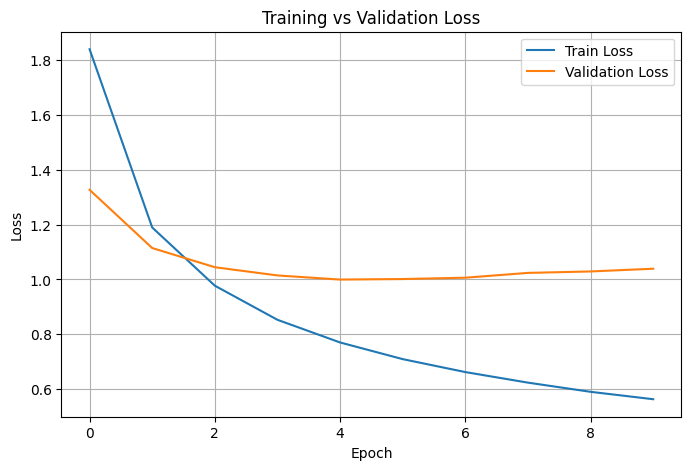

In [215]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [216]:
sos_id = SOS_ID
eos_id = EOS_ID

In [217]:
def batch_greedy_decode(
    model,
    sentences,
    tokenizer,
    max_len,
    sos_id,
    eos_id
):
    enc_inputs = [
        tokenizer(
            s,
            truncation=True,
            max_length=max_len
        )["input_ids"]
        for s in sentences
    ]

    max_src_len = max(len(x) for x in enc_inputs)
    enc_inputs = [
        x + [PAD_ID] * (max_src_len - len(x))
        for x in enc_inputs
    ]

    enc_tensor = tf.constant(enc_inputs, dtype=tf.int32)

    batch_size = len(sentences)
    dec_inputs = tf.constant([[sos_id]] * batch_size, dtype=tf.int32)

    finished = [False] * batch_size
    outputs = [[] for _ in range(batch_size)]

    for _ in range(max_len):
        preds = model([enc_tensor, dec_inputs], training=False)

        next_tokens = tf.argmax(preds[:, -1, :], axis=-1)
        next_tokens = tf.cast(next_tokens, tf.int32)

        dec_inputs = tf.concat(
            [dec_inputs, tf.expand_dims(next_tokens, 1)],
            axis=1
        )

        for i, tok in enumerate(next_tokens.numpy()):
            if not finished[i]:
                if tok == eos_id:
                    finished[i] = True
                else:
                    outputs[i].append(tok)

        if all(finished):
            break

    return [
        tokenizer.decode(
            o,
            skip_special_tokens=True
        )
        for o in outputs
    ]


In [218]:
BATCH_SIZE = 32

hypotheses = []
references = []

In [219]:
for i in trange(0, len(test_df), BATCH_SIZE):
    batch_df = test_df.iloc[i:i+BATCH_SIZE]

    src_batch = batch_df["en"].tolist()
    ref_batch = batch_df["id"].tolist()

    preds = batch_greedy_decode(
        transformer_model,
        src_batch,
        tokenizer,
        MAX_LEN_ID,
        sos_id,
        eos_id
    )

    hypotheses.extend(preds)
    references.extend(ref_batch)


100%|██████████| 310/310 [16:01<00:00,  3.10s/it]


In [220]:
pip install sacrebleu

In [221]:
from sacrebleu import corpus_bleu

In [222]:
for i in range(5):
    print("EN   :", test_df.iloc[i]["en"])
    print("REF  :", references[i])
    print("PRED :", hypotheses[i])
    print("-" * 60)

EN   : that thing, i'm not sure, but i think it was an acheri.
REF  : mahkluk itu, aku tidak yakin, tapi aku pikir itu adalah acheri.
PRED : itu, aku tidak yakin, tapi kurasa itu aku pikir itu
------------------------------------------------------------
EN   : please say yes.
REF  : kumohon katakan ya.
PRED : kumohon bilang ya.
------------------------------------------------------------
EN   : yeah... sure...
REF  : yeah...tentu saja...
PRED : ya...
------------------------------------------------------------
EN   : i think we did something to it.
REF  : kurasa kita harus melakukan sesuatu..
PRED : kurasa kita melakukan sesuatu untuk itu.
------------------------------------------------------------
EN   : give me the wallet!
REF  : selamatkan anak anak !
PRED : berikan aku dompet!
------------------------------------------------------------


Analisis :

- ada repetisi kata, decoder belum kuat dalam kekoheren kata pada sequence (kalimat 1)

- terjemahan sebagian hilang, EOS token sedikit terlalu cepat diprediksi (kalimat 3)

- arti teks missmatch, dataset noisy (kalimat 5)

In [223]:
bleu = corpus_bleu(hypotheses,  [references])

print(f"BLEU score: {bleu.score:.2f}")


BLEU score: 17.79


BLEU score 17.79 berarti kualitas terjemahan model masih di area menegah kebawah, tetapi ini berarti model udah mulai belajar sesuatu walau masih ada beberapa kesalahan

# Tokenizer + Embedding MarianMT

In [166]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

In [167]:
train_batch = tokenizer(
    train_df["en"].astype(str).tolist(),
    text_target=train_df["id"].astype(str).tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN_EN,
    return_tensors="pt"
)

In [168]:
input_ids = train_batch["input_ids"]
attention_mask = train_batch["attention_mask"]
labels = train_batch["labels"]

In [169]:
input_ids[:2]

tensor([[   30,    51,   334,   974,  2204,     6, 16509,   974,   101,     4,
             0, 54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795,
         54795, 54795, 54795, 54795, 54795],
        [  216,    27,     6,   977,     2,     2,     0, 54795, 54795, 54795,
         54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795,
         54795, 54795, 54795, 54795, 54795]])

In [170]:
attention_mask[:2]

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0]])

In [171]:
labels[:2]

tensor([[   33,  1020,    29,  1374,   634, 12606,    11, 26539,     4,     0,
         54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795,
         54795, 54795, 54795, 54795, 54795],
        [  230,   941,   607,    64,   150,     2,     2,     0, 54795, 54795,
         54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795, 54795,
         54795, 54795, 54795, 54795, 54795]])

In [172]:
val_batch = tokenizer(
    val_df["en"].astype(str).tolist(),
    text_target=val_df["id"].astype(str).tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN_EN,
    return_tensors="pt"
)



In [173]:
class TranslationDataset(Dataset):
    def __init__(self, train_batch):
        self.train_batch = train_batch

    def __len__(self):
        return self.train_batch["input_ids"].shape[0]

    def __getitem__(self, idx):
        return {
            "input_ids": self.train_batch["input_ids"][idx],
            "attention_mask": self.train_batch["attention_mask"][idx],
            "labels": self.train_batch["labels"][idx],
        }

train_dataset = TranslationDataset(train_batch)
val_dataset = TranslationDataset(val_batch)

In [174]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

# Grid Search Pretrained MarianMT

In [175]:
learning_rates = [1e-5, 3e-5, 5e-5]
weight_decays = [0.0, 0.01, 0.1]

In [ ]:
results = []

In [ ]:
param_grid = list(
    product(
        learning_rates,
        weight_decays
    )
)

In [ ]:
for lr, wd in tqdm(
    param_grid,
    desc="Grid Search"
):
    print(f"lr={lr}, wd={wd}")

    model = AutoModelForSeq2SeqLM.from_pretrained(
        MODEL_NAME
    )

    training_args = Seq2SeqTrainingArguments(
        output_dir=f"./results_lr{lr}_wd{wd}",
        num_train_epochs=2,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=lr,
        weight_decay=wd,
        save_strategy="epoch",
        eval_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),
        report_to="none"
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator
    )

    trainer.train()

    eval_res = trainer.evaluate()

    results.append({
        "lr": lr,
        "weight_decay": wd,
        "eval_loss": eval_res["eval_loss"]
    })

In [ ]:
results_df = pd.DataFrame(results)

In [ ]:
results_df = results_df.sort_values(
    by="eval_loss",
    ascending=True
)


In [ ]:
results_df

,lr,weight_decay,eval_loss
0,0.00001,0.00,0.448075
1,0.00001,0.01,0.448144
2,0.00001,0.10,0.448685
3,0.00003,0.00,0.482615
4,0.00003,0.01,0.482879
5,0.00003,0.10,0.485109
6,0.00005,0.00,0.522638
7,0.00005,0.01,0.523046
8,0.00005,0.10,0.526809


Didapat dari grid search, parameter terbaik :
weight_decay = 0.00
learning_rate = 0.00001


# Transformer Pretrained MarianMT

In [176]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./results",

    num_train_epochs=20,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=1e-5,
    weight_decay=0.00,

    save_strategy="epoch",
    eval_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    predict_with_generate=True,

    logging_steps=100,

    fp16=torch.cuda.is_available(),

    report_to="none"
)

In [177]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    data_collator=data_collator,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3
        )
    ]
)

In [178]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.515742,0.466725
2,0.426220,0.472081
3,0.412395,0.478626
4,0.400931,0.486858


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.encoder.embed_positions.weight', 'model.decoder.embed_tokens.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


TrainOutput(global_step=39624, training_loss=0.4482711717236675, metrics={'train_runtime': 2800.5369, 'train_samples_per_second': 565.899, 'train_steps_per_second': 70.744, 'total_flos': 2098547136921600.0, 'train_loss': 0.4482711717236675, 'epoch': 4.0})

# Testing Pretrained MarianMT

In [179]:
model = trainer.model

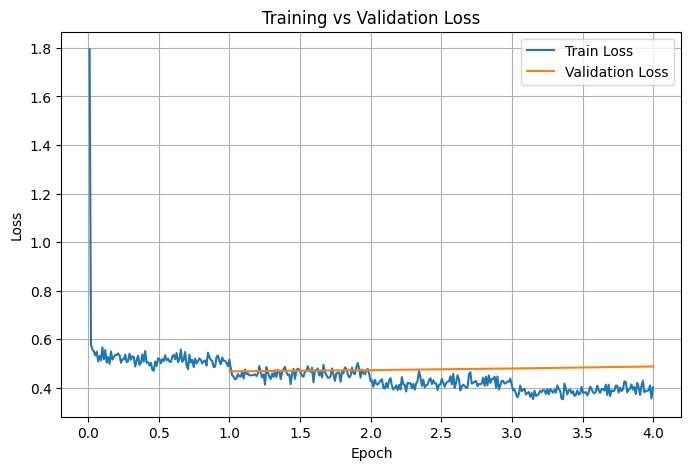

In [180]:
logs = pd.DataFrame(trainer.state.log_history)

train_logs = logs[logs["loss"].notna()]
eval_logs = logs[logs["eval_loss"].notna()]

plt.figure(figsize=(8, 5))

plt.plot(
    train_logs["epoch"],
    train_logs["loss"],
    label="Train Loss"
)

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [181]:
def batch_translate(
    model,
    tokenizer,
    sentences,
    max_len=MAX_LEN_ID
):
    inputs = tokenizer(
        sentences,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(model.device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_len,
            num_beams=4,
            early_stopping=True
        )

    preds = tokenizer.batch_decode(
        outputs,
        skip_special_tokens=True
    )

    return preds

In [182]:
BATCH_SIZE = 32

hypotheses = []
references = []

for i in trange(0, len(test_df), BATCH_SIZE):

    batch_df = test_df.iloc[i:i+BATCH_SIZE]

    src_batch = batch_df["en"].tolist()
    ref_batch = batch_df["id"].tolist()

    preds = batch_translate(
        model,
        tokenizer,
        src_batch,
        max_len=MAX_LEN_ID
    )

    hypotheses.extend(preds)
    references.extend(ref_batch)

100%|██████████| 310/310 [01:45<00:00,  2.94it/s]


In [183]:
for i in range(5):
    print("EN   :", test_df.iloc[i]["en"])
    print("REF  :", references[i])
    print("PRED :", hypotheses[i])
    print("-" * 60)

EN   : that thing, i'm not sure, but i think it was an acheri.
REF  : mahkluk itu, aku tidak yakin, tapi aku pikir itu adalah acheri.
PRED : hal itu, saya tidak yakin, tapi saya pikir itu adalah acheri.
------------------------------------------------------------
EN   : please say yes.
REF  : kumohon katakan ya.
PRED : tolong katakan ya.
------------------------------------------------------------
EN   : yeah... sure...
REF  : yeah...tentu saja...
PRED : ya... tentu...
------------------------------------------------------------
EN   : i think we did something to it.
REF  : kurasa kita harus melakukan sesuatu..
PRED : aku pikir kita melakukan sesuatu untuk itu.
------------------------------------------------------------
EN   : give me the wallet!
REF  : selamatkan anak anak !
PRED : berikan dompet itu!
------------------------------------------------------------


Analisis :
- Terjemahan sudah benar secara umum, tetapi terkadang kurang konteks semantik (kalimat 1, hal itu seharusnya makhluk itu dan kalimat 2 tolong seharusnya kumohon). Ini masih accpetable
- Terjemahan terkadang lebih baik dari refrensinya, bahkan referensinya kadang salah arti. kemungkinan karena dataset yang kotor (kalimat 4 dan kalimat 5)


In [184]:
pip install sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.8 MB/s eta 0:00:00


In [185]:
from sacrebleu import corpus_bleu

In [186]:
bleu = corpus_bleu(hypotheses,  [references])

print(f"BLEU score: {bleu.score:.2f}")


BLEU score: 35.31


Model memiliki bleu score 35.31 yang berarti sudah cukup bagus, tetapi ada beberapa hal yang membuat bleu score sedikit lebih rendah seperti : 
- Perbedaan pilihan kata , model sering menggunakan sinonim yang benar secara makna, tetapi berbeda dengan reference 
- Kehilangan intensitas makna, beberapa terjemahan kehilangan tingkat kesopanan atau emosi
- Dataset referensi yang noisy, beberapa referensi sepertinya belum sesuai dengan input bahasa Inggris, sehingga bleu score turun


# Analisis Perbandingan kedua Model :

1 Perbandingan Performa Kedua Model

(-) Berdasarkan BLEU score:

Transformer from Scratch menghasilkan BLEU score sebesar 17.79, sedangkan MarianMT yang di-fine-tuning memperoleh BLEU score 35.31.

Hasil ini menunjukkan bahwa MarianMT memiliki performa yang jauh lebih baik. Jika dihitung, peningkatannya mencapai sekitar 98,5% ((35.31-17.79)/17.79 * 100%) dibandingkan Transformer Scratch. Dengan kata lain, hasil terjemahan MarianMT jauh lebih mendekati kalimat referensi yang ada pada dataset.

Namun, BLEU score bukan satu-satunya hal yang perlu diperhatikan. Karena itu, hasil terjemahan juga dianalisis secara langsung untuk melihat kualitasnya dari sudut pandang manusia.

(-) Berdasarkan human evaluation

(*) Contoh 1:

Input: that thing, i'm not sure, but i think it was an acheri.

Reference: mahkluk itu, aku tidak yakin, tapi aku pikir itu adalah acheri.

Transformer Scratch: itu, aku tidak yakin, tapi kurasa itu aku pikir itu

MarianMT: hal itu, saya tidak yakin, tapi saya pikir itu adalah acheri.

Terlihat bahwa Transformer Scratch mengalami pengulangan kata dan kehilangan informasi penting, yaitu kata acheri. Selain itu susunan kalimatnya juga terasa kurang alami.

Sebaliknya, MarianMT masih mampu mempertahankan makna utama dari kalimat sumber. Struktur kalimatnya lebih rapi dan tidak mengalami pengulangan kata yang tidak perlu.

(*) Contoh 2:

Input: yeah... sure...

Reference: yeah... tentu saja...

Transformer Scratch: ya...

MarianMT: ya... tentu...

Pada kasus ini Transformer Scratch menghentikan terjemahan terlalu cepat sehingga sebagian makna hilang. Sementara itu MarianMT masih berhasil mempertahankan informasi yang ingin disampaikan meskipun tidak identik dengan referensi.

Secara umum, MarianMT menghasilkan terjemahan yang lebih lengkap, lebih konsisten, dan lebih natural. Sementara Transformer Scratch masih menunjukkan beberapa masalah seperti pengulangan kata, hilangnya sebagian terjemahan (missing translation), serta kecenderungan memprediksi token akhir kalimat (EOS) terlalu cepat.

(-) Hasil BLEU Score

BLEU score merupakan metrik yang sangat populer untuk mengevaluasi sistem penerjemahan, tetapi sebenarnya metrik ini belum sepenuhnya mampu menggambarkan kualitas terjemahan secara utuh. 

Contohnya: 

Reference: kumohon katakan ya

Prediksi: tolong katakan ya

maknanya sama tapi BLEU tetap mengurangi skor karena token tidak identik.

Selain itu dataset yang digunakan juga masih memiliki noise. Contoh:

Input: give me the wallet!

Reference: Selamatkan anak-anak!

Prediksi MarianMT: berikan dompet itu!

Justru prediksi model lebih masuk akal dibanding referensi, tetapi BLEU tetap menghukum model karena referensi dianggap ground truth

Jadi BLEU tetap penting karena objektif dan mudah dibandingkan tapi BLEU harus dilengkapi dengan human evaluation, analisis contoh terjemahan, dan semantic similarity metric (misalnya BERTScore) supaya kualitas model bisa dinilai dengan lebih adil.

(-) Analisis Hyperparameter terbaik

(*) Transformer Scratch

Dari hasil grid search, kombinasi hyperparameter terbaik adalah: Number of layers = 2, learning rate = 0.0005

Menariknya, penambahan jumlah layer tidak selalu meningkatkan performa model. Secara teori model yang lebih dalam memang memiliki kapasitas yang lebih besar untuk belajar pola yang kompleks. Namun di proyek ini hasil terbaik justru diperoleh ketika menggunakan 2 layer.

Kemungkinan penyebabnya adalah kualitas dataset yang masih belum sepenuhnya bersih. Meskipun sudah dilakukan preprocessing, masih terdapat beberapa pasangan kalimat yang kurang selaras dan mengandung noise. Pada kondisi seperti ini, model yang terlalu kompleks justru lebih mudah mempelajari pola yang salah dari data.

Alasan learning rate 0.0005 terbaik karena cukup cepat belajar dan tetap stabil jadi menghasilkan validation loss terendah

(*) MarianMT

Untuk MarianMT, hasil terbaik diperoleh dengan: Learning Rate = 1e-5, Weight Decay = 0.

Learning rate yang kecil memang umum digunakan pada proses fine-tuning model pre-trained. Hal ini karena MarianMT sudah memiliki pengetahuan bahasa yang diperoleh dari proses pre-training sebelumnya. Jika learning rate terlalu besar, bobot yang sudah baik tersebut dapat berubah terlalu drastis sehingga performa justru menurun.

Sementara itu, penggunaan weight decay tidak memberikan peningkatan performa. Kemungkinan karena MarianMT sudah memiliki kemampuan generalisasi yang baik dari proses pre-training, sehingga regularisasi tambahan melalui weight decay tidak terlalu diperlukan.

(-) Analisis Kurva Loss

(*) Transformer Scratch:

Dari grafik terlihat bahwa train loss terus menurun selama proses training. Validation loss juga mengalami penurunan pada beberapa epoch awal, tetapi mulai meningkat kembali setelah sekitar epoch ke-5.

Pola seperti ini biasanya menunjukkan bahwa model mulai mengalami overfitting. Model semakin baik dalam menghafal data training, tetapi kemampuan generalisasinya terhadap data yang belum pernah dilihat mulai menurun.

Karena itu, penggunaan early stopping cukup membantu dengan mengembalikan bobot model terbaik yang diperoleh pada epoch ke-5.

(*) MarianMT

Pada MarianMT, train loss dan validation loss memiliki jarak yang relatif kecil. Validation loss juga cenderung stabil sepanjang proses training.

Hal ini menunjukkan bahwa model mampu melakukan generalisasi dengan lebih baik dibandingkan Transformer Scratch. Salah satu alasan utamanya adalah karena MarianMT sudah memiliki pengetahuan awal dari proses pre-training sehingga tidak perlu belajar semuanya dari nol.

# Kesimpulan

(-) Berdasarkan hasil eksperimen yang telah dilakukan, MarianMT yang di-fine-tuning menjadi model dengan performa terbaik. Hal ini terlihat dari nilai BLEU Score yang lebih tinggi, kualitas hasil terjemahan yang lebih baik, hasil evaluasi secara manual yang lebih konsisten, serta proses training yang lebih stabil dibandingkan Transformer yang dibangun dari nol. Secara umum, MarianMT mampu menghasilkan terjemahan yang lebih natural, lebih lengkap, dan lebih mampu mempertahankan makna dari kalimat sumber.

(-) Untuk hyperparameter, konfigurasi terbaik pada Transformer Scratch diperoleh saat menggunakan 2 layer dan learning rate 0.0005. Menariknya, penambahan jumlah layer tidak memberikan peningkatan performa. Bahkan model dengan jumlah layer yang lebih sedikit justru menghasilkan validation loss yang lebih rendah. Kemungkinan hal ini terjadi karena dataset yang digunakan masih mengandung noise dan beberapa pasangan kalimat yang kurang selaras, sehingga model yang lebih kompleks cenderung lebih mudah mempelajari pola yang tidak diinginkan.

Sementara itu, pada MarianMT, kombinasi hyperparameter terbaik adalah learning rate 1e-5 dan weight decay 0. Learning rate yang kecil membantu proses fine-tuning berjalan lebih stabil tanpa merusak pengetahuan yang telah dipelajari model selama tahap pre-training.

(-) Meskipun BLEU Score sering digunakan sebagai metrik utama dalam evaluasi sistem translasi, metrik ini belum sepenuhnya mampu menggambarkan kualitas terjemahan yang sebenarnya. BLEU hanya mengukur tingkat kesamaan token dengan kalimat referensi. Dalam praktiknya, sebuah terjemahan bisa saja menggunakan sinonim, variasi gaya bahasa, atau pilihan kata yang berbeda tetapi tetap memiliki makna yang sama. Selain itu, beberapa pasangan kalimat pada dataset juga ditemukan kurang sesuai, sehingga dapat menurunkan nilai BLEU meskipun hasil terjemahan model sebenarnya sudah benar secara makna. Oleh karena itu, evaluasi translasi sebaiknya tidak hanya mengandalkan BLEU Score, tetapi juga dilengkapi dengan human evaluation untuk menilai kelancaran bahasa, kesesuaian makna, dan naturalitas terjemahan.

(-) Langkah yang bisa meningkatkan model:

(1) Membersihkan dataset lebih lanjut untuk mengurangi noise dan pasangan kalimat yang tidak selaras.

(2) Menambahkan data paralel Inggris–Indonesia yang berkualitas lebih tinggi.

(3) Melakukan hyperparameter tuning yang lebih luas (batch size, dropout, beam width, epoch).

(4) Menggunakan decoding yang lebih baik seperti beam search yang lebih besar.

(5) Menggunakan model translasi yang lebih modern seperti mBART atau NLLB.

Tapi masih terdapat satu faktor yang sulit diperbaiki sepenuhnya yaitu kualitas dataset. Kalau data masih mengandung pasangan kalimat yang salah maka performa model akan tetap memiliki batas tertentu meskipun arsitektur dan hyperparameter terus ditingkatkan